Exploring data

In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/Metro_Interstate_Traffic_Volume.csv.gz")
print(df.shape)
df.head()

(48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [2]:
df.info()
df.describe()
df["date_time"].duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB


np.int64(7629)

In [3]:
import numpy as np

df.loc[df["temp"] == 0, "temp"] = np.nan


df.loc[df["rain_1h"] > 100, "rain_1h"] = np.nan


print(df["temp"].isna().sum())
print(df["rain_1h"].isna().sum())

10
1


In [4]:
df["date_time"].duplicated().sum()

np.int64(7629)

In [5]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48194.000000,48203.000000,48204.000000,48204.000000,48204.000000
mean,281.264219,0.130315,0.000222,49.362231,3259.818355
std,12.709587,1.003378,0.008168,39.015750,1986.860670
min,243.390000,0.000000,0.000000,0.000000,0.000000
25%,272.182500,0.000000,0.000000,1.000000,1193.000000
50%,282.460000,0.000000,0.000000,64.000000,3380.000000
75%,291.810000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,55.630000,0.510000,100.000000,7280.000000


In [6]:

df["date_time"].duplicated().sum()

np.int64(7629)

In [7]:

df["date_time"].duplicated().sum()
df["holiday"].value_counts()

holiday
Labor Day                    7
Thanksgiving Day             6
Christmas Day                6
New Years Day                6
Martin Luther King Jr Day    6
Columbus Day                 5
Veterans Day                 5
Washingtons Birthday         5
Memorial Day                 5
Independence Day             5
State Fair                   5
Name: count, dtype: int64

In [8]:
df[df["date_time"].duplicated(keep=False)].head(10)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
178,NaN,281.25,0.0,0.0,99,Rain,light rain,2012-10-10 07:00:00,6793
179,NaN,281.25,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 07:00:00,6793
180,NaN,280.10,0.0,0.0,99,Rain,light rain,2012-10-10 08:00:00,6283
181,NaN,280.10,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 08:00:00,6283
182,NaN,279.61,0.0,0.0,99,Rain,light rain,2012-10-10 09:00:00,5680
183,NaN,279.61,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 09:00:00,5680
269,NaN,282.43,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 09:00:00,2685
270,NaN,282.43,0.0,0.0,57,Mist,mist,2012-10-14 09:00:00,2685
271,NaN,282.43,0.0,0.0,57,Haze,haze,2012-10-14 09:00:00,2685
272,NaN,282.33,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 10:00:00,3370


In [9]:
df.groupby("date_time")["traffic_volume"].nunique().max()

np.int64(1)

In [10]:
X=df["holiday"].notna()
df[X][["holiday", "date_time"]]

,holiday,date_time
126,Columbus Day,2012-10-08 00:00:00
1123,Veterans Day,2012-11-12 00:00:00
1370,Thanksgiving Day,2012-11-22 00:00:00
2360,Christmas Day,2012-12-25 00:00:00
2559,New Years Day,2013-01-01 00:00:00
...,...,...
44441,Memorial Day,2018-05-28 00:00:00
45547,Independence Day,2018-07-04 00:00:00
46936,State Fair,2018-08-23 00:00:00
47330,Labor Day,2018-09-03 00:00:00


In [11]:
df["date_time"] = pd.to_datetime(df["date_time"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     str           
 1   temp                 48194 non-null  float64       
 2   rain_1h              48203 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  str           
 6   weather_description  48204 non-null  str           
 7   date_time            48204 non-null  datetime64[us]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 4.1 MB


In [12]:
len(df[df["temp"] == 0])

0

In [13]:
len(df[df["rain_1h"] >= 100])

0

In [14]:
zeros = df[df["traffic_volume"] == 0]
print(len(zeros))
zeros["date_time"]

2


25186   2016-07-23 18:00:00
25191   2016-07-23 23:00:00
Name: date_time, dtype: datetime64[us]

In [15]:
df.loc[25180:25195]

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
25180,NaN,295.55,0.00,0.0,75,Rain,light rain,2016-07-23 15:00:00,3
25181,NaN,295.55,0.00,0.0,75,Thunderstorm,proximity thunderstorm,2016-07-23 15:00:00,3
25182,NaN,295.22,10.67,0.0,90,Rain,heavy intensity rain,2016-07-23 16:00:00,7
25183,NaN,295.22,10.67,0.0,90,Mist,mist,2016-07-23 16:00:00,7
25184,NaN,295.54,0.51,0.0,90,Rain,moderate rain,2016-07-23 17:00:00,5
25185,NaN,295.54,0.51,0.0,90,Mist,mist,2016-07-23 17:00:00,5
25186,NaN,296.68,0.00,0.0,40,Rain,light rain,2016-07-23 18:00:00,0
25187,NaN,297.48,0.00,0.0,40,Clouds,scattered clouds,2016-07-23 19:00:00,1
25188,NaN,297.21,0.00,0.0,20,Clouds,few clouds,2016-07-23 20:00:00,5
25189,NaN,296.47,0.00,0.0,20,Clouds,few clouds,2016-07-23 21:00:00,2


In [16]:

mask = (df["date_time"] >= "2016-07-23 06:00") & (df["date_time"] <= "2016-07-24 20:00")


period = df.loc[mask, ["date_time", "traffic_volume"]].drop_duplicates(subset="date_time")

print(len(period))
print(period.to_string())

39
                date_time  traffic_volume
25163 2016-07-23 06:00:00            1350
25164 2016-07-23 07:00:00            1868
25165 2016-07-23 08:00:00            2497
25166 2016-07-23 09:00:00              15
25167 2016-07-23 10:00:00               3
25168 2016-07-23 11:00:00              24
25171 2016-07-23 12:00:00               2
25174 2016-07-23 13:00:00              10
25178 2016-07-23 14:00:00               2
25180 2016-07-23 15:00:00               3
25182 2016-07-23 16:00:00               7
25184 2016-07-23 17:00:00               5
25186 2016-07-23 18:00:00               0
25187 2016-07-23 19:00:00               1
25188 2016-07-23 20:00:00               5
25189 2016-07-23 21:00:00               2
25190 2016-07-23 22:00:00               1
25191 2016-07-23 23:00:00               0
25192 2016-07-24 00:00:00               6
25193 2016-07-24 01:00:00               8
25194 2016-07-24 02:00:00               5
25195 2016-07-24 03:00:00               3
25198 2016-07-24 04:00:00      

In [17]:
temp_zero=(df[df["temp"] == 0])
temp_zero["date_time"]


Series([], Name: date_time, dtype: datetime64[us])

In [18]:
hour = df["date_time"].dt.hour
daytime = (hour >= 7) & (hour <= 19)
low = df["traffic_volume"] < 100

suspect = df[daytime & low]
print(len(suspect))
suspect["date_time"]

27


16849   2015-07-25 08:00:00
16850   2015-07-25 09:00:00
25166   2016-07-23 09:00:00
25167   2016-07-23 10:00:00
25168   2016-07-23 11:00:00
25169   2016-07-23 11:00:00
25170   2016-07-23 11:00:00
25171   2016-07-23 12:00:00
25172   2016-07-23 12:00:00
25173   2016-07-23 12:00:00
25174   2016-07-23 13:00:00
25175   2016-07-23 13:00:00
25176   2016-07-23 13:00:00
25177   2016-07-23 13:00:00
25178   2016-07-23 14:00:00
25179   2016-07-23 14:00:00
25180   2016-07-23 15:00:00
25181   2016-07-23 15:00:00
25182   2016-07-23 16:00:00
25183   2016-07-23 16:00:00
25184   2016-07-23 17:00:00
25185   2016-07-23 17:00:00
25186   2016-07-23 18:00:00
25187   2016-07-23 19:00:00
25204   2016-07-24 09:00:00
25206   2016-07-24 11:00:00
25211   2016-07-24 16:00:00
Name: date_time, dtype: datetime64[us]

In [19]:
X = (df["date_time"] >= "2016-07-22") & (df["date_time"] <= "2016-07-26")
week = df[X]

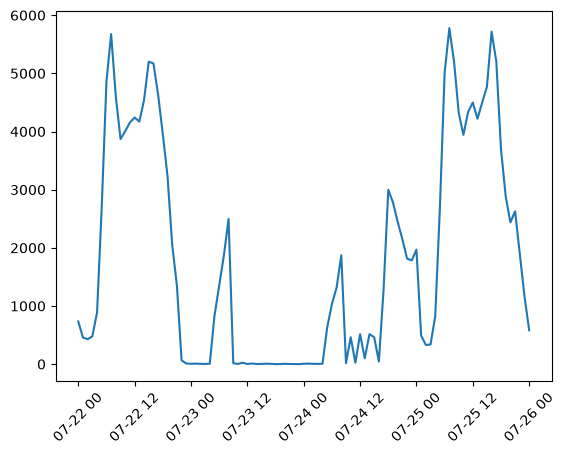

In [20]:
import matplotlib.pyplot as plt
plt.plot(week["date_time"],week["traffic_volume"])
plt.xticks(rotation=45)
plt.show()

In [21]:
import numpy as np


df.loc[df["temp"] == 0, "temp"] = np.nan


df.loc[df["rain_1h"] > 100, "rain_1h"] = np.nan

print(df["temp"].isna().sum())
print(df["rain_1h"].isna().sum())

10
1


In [22]:

mask = (df["date_time"] >= "2016-07-23 06:00") & (df["date_time"] <= "2016-07-24 20:00")


period = df.loc[mask, ["date_time", "traffic_volume"]].drop_duplicates(subset="date_time")

print(len(period))
print(period.to_string())

39
                date_time  traffic_volume
25163 2016-07-23 06:00:00            1350
25164 2016-07-23 07:00:00            1868
25165 2016-07-23 08:00:00            2497
25166 2016-07-23 09:00:00              15
25167 2016-07-23 10:00:00               3
25168 2016-07-23 11:00:00              24
25171 2016-07-23 12:00:00               2
25174 2016-07-23 13:00:00              10
25178 2016-07-23 14:00:00               2
25180 2016-07-23 15:00:00               3
25182 2016-07-23 16:00:00               7
25184 2016-07-23 17:00:00               5
25186 2016-07-23 18:00:00               0
25187 2016-07-23 19:00:00               1
25188 2016-07-23 20:00:00               5
25189 2016-07-23 21:00:00               2
25190 2016-07-23 22:00:00               1
25191 2016-07-23 23:00:00               0
25192 2016-07-24 00:00:00               6
25193 2016-07-24 01:00:00               8
25194 2016-07-24 02:00:00               5
25195 2016-07-24 03:00:00               3
25198 2016-07-24 04:00:00      

In [23]:
# 1) Mark the anomaly period as NaN (no filling, so we don't fabricate traffic data)
bad = (df["date_time"] >= "2016-07-23 09:00") & (df["date_time"] <= "2016-07-24 16:00")
df.loc[bad, "traffic_volume"] = np.nan

In [24]:
# 2) Look at Jul 25, 2015 hours before deciding
chk = (df["date_time"] >= "2015-07-25 04:00") & (df["date_time"] <= "2015-07-25 14:00")
print(df.loc[chk, ["date_time", "traffic_volume"]].drop_duplicates("date_time").to_string())


                date_time  traffic_volume
16843 2015-07-25 04:00:00           258.0
16844 2015-07-25 05:00:00           283.0
16846 2015-07-25 06:00:00           241.0
16848 2015-07-25 07:00:00           190.0
16849 2015-07-25 08:00:00             1.0
16850 2015-07-25 09:00:00             1.0
16851 2015-07-25 10:00:00          1990.0
16852 2015-07-25 11:00:00          2721.0
16853 2015-07-25 12:00:00          3068.0
16854 2015-07-25 13:00:00          3252.0
16855 2015-07-25 14:00:00          3095.0


In [25]:
# 3) is_holiday column: spread the holiday flag over all hours of that day
df["date"] = df["date_time"].dt.normalize()
holiday_dates = df.loc[df["holiday"].notna(), "date"].unique()
df["is_holiday"] = df["date"].isin(holiday_dates).astype(int)

In [26]:
# 4) Merge duplicate hours: one row per hour
agg = {
    "temp": "mean", "rain_1h": "mean", "snow_1h": "mean", "clouds_all": "mean",
    "weather_main": "first", "weather_description": "first",
    "traffic_volume": "first", "is_holiday": "max",
}
hourly = df.groupby("date_time").agg(agg).reset_index()

In [27]:
# 5) Checks
print(hourly.shape) # المتوقع 40575 سطر | expected 40575 rows
print(hourly["traffic_volume"].isna().sum()) # المتوقع 32 | expected 32
print(hourly["is_holiday"].sum()) # عدد ساعات العطل | number of holiday hours
print(hourly["temp"].isna().sum(), hourly["rain_1h"].isna().sum())

(40575, 9)
32
1203
10 1


In [28]:
out15 = (hourly["date_time"] >= "2015-07-25 08:00") & (hourly["date_time"] <= "2015-07-25 09:00")
hourly.loc[out15, "traffic_volume"] = np.nan
print(hourly["traffic_volume"].isna().sum())

34


In [29]:
diffs = hourly["date_time"].diff()
gap_df = pd.DataFrame({
    "gap_ends_at": hourly["date_time"],
    "missing_hours": diffs / pd.Timedelta(hours=1) - 1,
 })
gap_df = gap_df[gap_df["missing_hours"] > 0]

In [30]:

print(len(gap_df))                          
print(gap_df["missing_hours"].sum())        
print(gap_df["missing_hours"].describe()) 
print(gap_df.sort_values("missing_hours", ascending=False).head(10))

2588
11976.0
count    2588.000000
mean        4.627512
std       145.299803
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max      7386.000000
Name: missing_hours, dtype: float64
              gap_ends_at  missing_hours
13898 2015-06-11 20:00:00         7386.0
8131  2013-11-06 04:00:00          242.0
13905 2015-06-19 18:00:00          117.0
12188 2014-05-04 05:00:00          116.0
16596 2015-10-27 08:00:00           92.0
13737 2014-07-30 09:00:00           64.0
7339  2013-09-01 23:00:00           46.0
13909 2015-06-24 04:00:00           33.0
13800 2014-08-03 11:00:00           32.0
7365  2013-09-04 08:00:00           29.0


In [31]:
full_index = pd.date_range(hourly["date_time"].min(), hourly["date_time"].max(), freq="h")
clean = hourly.set_index("date_time").reindex(full_index)
clean.index.name = "date_time"

In [33]:
for col in ["temp", "rain_1h", "snow_1h", "clouds_all"]:
        clean[col] = clean[col].interpolate(method="time", limit=3, limit_area="inside")

In [34]:
clean["is_holiday"] = clean.index.normalize().isin(holiday_dates).astype(int)


In [ ]:
print(clean.shape)                            
print(clean["traffic_volume"].notna().sum())   
print(clean["traffic_volume"].isna().sum())    
print(clean[["temp", "rain_1h"]].isna().sum())

(52551, 8)
40541
12010
temp       8472
rain_1h    8472
dtype: int64


In [36]:
clean.reset_index().to_csv("../data/processed/traffic_hourly_clean.csv", index=False)